In [3]:
from autocleanse.utils import load_csv
from autocleanse.cleaner import handle_missing_data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import pandas as pd

In [16]:
df = load_csv("../data/train.csv")
df = handle_missing_data(df)
df['Is_Alone'] = ((df['SibSp'] + df['Parch']) == 0).astype(int)
df = df.drop(columns=['Name', 'Ticket', 'Parch', 'SibSp'], axis=1)
columns = [column for column in df.columns if df[column].nunique() / len(df) < 0.05]
columns.remove('Survived')
print(columns)

Started Cleaning the Data...
Finished Cleaning the Data!
['Pclass', 'Sex', 'Embarked', 'Is_Alone']


In [6]:
df_encoded = pd.get_dummies(data= df, columns= columns)
df_encoded.columns

Index(['Survived', 'Age', 'Fare', 'Pclass_1', 'Pclass_2', 'Pclass_3',
       'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'Is_Alone_0', 'Is_Alone_1'],
      dtype='object')

In [7]:
X = df_encoded.drop('Survived', axis= 1)
y = df_encoded['Survived']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [11]:
# Look at raw predictions
print(y_pred[:10])  # First 10 predicted labels (0 or 1)
print(y_test[:10].values)  # First 10 actual labels

[0 0 1 0 1 0 0 1 0 1]
[0 0 1 0 1 0 0 1 1 1]


In [12]:
acc = accuracy_score(y_test, y_pred=y_pred)
print(f"Accuracy: {acc:.2f}")

Accuracy: 0.77


[[107  19]
 [ 32  65]]


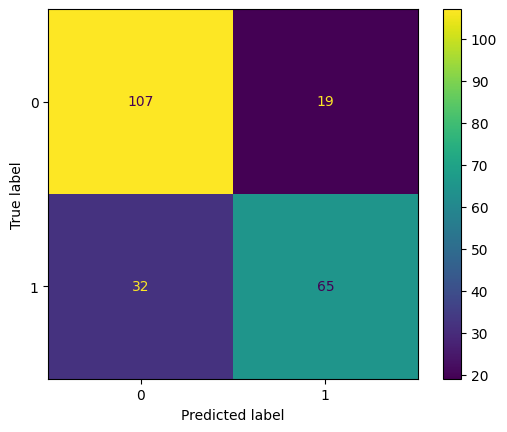

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.77      0.85      0.81       126
           1       0.77      0.67      0.72        97

    accuracy                           0.77       223
   macro avg       0.77      0.76      0.76       223
weighted avg       0.77      0.77      0.77       223



In [15]:
import joblib

joblib.dump(model, '../data/titanic_model.pkl')
joblib.dump(scaler, '../data/titanic_scaler.pkl')
# After creating X_train and before scaling
training_columns = X_train.columns
joblib.dump(training_columns, 'training_columns.pkl')


['training_columns.pkl']